# Word2Vec (4/4): Preprocesamiento real de textos — limpieza, duplicados, lematización y tokenización

En este notebook trabajamos con un caso más real usando el archivo **`retos_culturales_colombia.xlsx`** y tomando como referencia tu notebook preliminar.

La idea es construir un flujo de preprocesamiento más sólido para dejar los textos **listos para entrenar Word2Vec**.

## Objetivos

Al finalizar este notebook podrás:

- cargar y revisar el conjunto de datos real,
- limpiar textos de forma reproducible,
- detectar y remover duplicados,
- normalizar espacios, signos y ruido textual,
- tokenizar y lematizar en español con **spaCy**,
- construir un corpus final listo para **Word2Vec**,
- exportar artefactos limpios para reutilizarlos después.

## Diferencias frente al notebook preliminar

Tu notebook original hacía varias tareas importantes:
- pasaba a minúsculas,
- quitaba puntuación,
- quitaba stopwords,
- exploraba n-gramas,
- usaba `CountVectorizer`, `TF-IDF` y clustering.

Aquí vamos a reorganizar esa lógica en un pipeline más claro, especialmente pensando en **embeddings**.  
Para Word2Vec, nos interesa que el texto quede limpio, consistente y tokenizado correctamente.


## 0. Instalación sugerida

Si te hace falta algún paquete, puedes instalarlo así:

```bash
pip install pandas openpyxl spacy gensim matplotlib
python -m spacy download es_core_news_sm
```

> Este notebook usa **spaCy** para tokenización y lematización en español.  
> Si el modelo `es_core_news_sm` no está instalado, el notebook intentará usar `spacy.blank("es")`, pero en ese caso la **lematización será limitada**.


In [1]:
from __future__ import annotations

import re
import unicodedata
from pathlib import Path
from typing import Dict, List, Sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import spacy


In [2]:
def load_spacy_model(preferred: str = "es_core_news_sm"):
    try:
        return spacy.load(preferred)
    except Exception:
        lang = preferred.split("_")[0] if "_" in preferred else "es"
        print(
            f"[WARN] Could not load '{preferred}'. Falling back to spacy.blank('{lang}').\n"
            f"       To install the model: python -m spacy download {preferred}"
        )
        return spacy.blank(lang)


nlp = load_spacy_model("es_core_news_sm")


## 1. Carga de datos

Trabajaremos con el archivo de Excel que compartiste.  
La columna principal de texto es **`Reto`**.


In [3]:
DATA_PATH = Path("data/retos_culturales_colombia.xlsx")

df = pd.read_excel(DATA_PATH)
df.head()


,ID,Reto
0,1.0,el mayor reto es poder actualizar el desarroll...
1,2.0,La implementación de políticas públicas que pr...
2,3.0,En nuestro territorio considero de vital impor...
3,4.0,Darle la importancia que se merece este sector
4,5.0,Apoyar los eventos Culturales desde los territ...


In [4]:
df.shape, df.columns.tolist()


((14376, 2), ['ID', 'Reto'])

## 2. Revisión rápida de calidad del dato

Antes de limpiar, conviene revisar:
- valores nulos,
- textos vacíos,
- longitud aproximada,
- duplicados exactos.


In [5]:
df["Reto"] = df["Reto"].astype("string")

summary = pd.DataFrame({
    "n_rows": [len(df)],
    "n_null_text": [df["Reto"].isna().sum()],
    "n_empty_after_strip": [df["Reto"].fillna("").str.strip().eq("").sum()],
    "n_exact_duplicates": [df["Reto"].duplicated().sum()],
    "avg_length_chars": [df["Reto"].fillna("").str.len().mean()],
    "median_length_chars": [df["Reto"].fillna("").str.len().median()],
})
summary


,n_rows,n_null_text,n_empty_after_strip,n_exact_duplicates,avg_length_chars,median_length_chars
0,14376,0,0,461,272.610601,182.0


In [6]:
df["Reto"].dropna().sample(5, random_state=7).tolist()


['Mantener la cultura en un municipio ',
 'El mayor reto que debe asumir el Ministerio de cultura es la preservación de las diferentes culturas que existen en el País. pata esto es necesario que se destine un recurso mucho más amplio al patrimonio cultural, que no dependa del consumo de la telefonía móvil, así como tampoco dependa de la distribución de lo departamentos, sino que a cada municipio debería transferir recursos específicos para la inversión en patrimonio cultural. ',
 'El mayor reto para la cultura hoy y mañana es el reconocimiento de  las expresiones de todos los ciudadanos sin limitaciones ni discriminaciones y la participación motivada con capacitación en políticas culturales, disciplinas artísticas para todas la edades, estrategias de investigación, promoción y circulación de productos, así sean sencillos. Además, promover la  industria cultural de pequeños formatos. \nEvitar las exageradas exigencias para participar en los concursos y estímulos donde para demostrar ant

## 3. Funciones de limpieza textual

Vamos a separar dos niveles de limpieza:

### 3.1. Limpieza base
Pensada para análisis exploratorio y trazabilidad:
- minúsculas,
- quitar saltos de línea,
- quitar URLs y correos,
- normalizar espacios,
- quitar signos de puntuación “ruidosos”,
- conservar tildes y caracteres del español.

### 3.2. Normalización para deduplicación
Pensada para detectar textos repetidos aunque cambien pequeños detalles:
- minúsculas,
- sin tildes,
- sin puntuación,
- sin espacios duplicados.

Esto permite distinguir entre:
- **texto limpio para modelar**, y
- **texto normalizado para comparar duplicados**.


In [7]:
def remove_accents(text: str) -> str:
    """Remove accents while preserving base characters."""
    text = unicodedata.normalize("NFKD", text)
    return "".join(ch for ch in text if not unicodedata.combining(ch))


def basic_clean_text(text: str) -> str:
    """Perform a conservative cleaning suitable for NLP preprocessing."""
    if text is None or pd.isna(text):
        return ""

    text = str(text).lower()
    text = text.replace("\n", " ").replace("\r", " ").replace("\t", " ")

    # Remove URLs and emails
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)

    # Keep letters, numbers and common Spanish punctuation boundaries as spaces
    text = re.sub(r"[^\w\sáéíóúüñ]", " ", text, flags=re.UNICODE)

    # Remove isolated numbers if desired for this corpus
    text = re.sub(r"\b\d+\b", " ", text)

    # Normalize spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


def normalized_text_for_dedup(text: str) -> str:
    """Create a normalized representation for duplicate detection."""
    text = basic_clean_text(text)
    text = remove_accents(text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


In [8]:
df["text_raw"] = df["Reto"].fillna("").astype(str)
df["text_clean"] = df["text_raw"].apply(basic_clean_text)
df["text_norm_dedup"] = df["text_raw"].apply(normalized_text_for_dedup)

df[["ID", "text_raw", "text_clean", "text_norm_dedup"]].head(3)


,ID,text_raw,text_clean,text_norm_dedup
0,1.0,el mayor reto es poder actualizar el desarroll...,el mayor reto es poder actualizar el desarroll...,el mayor reto es poder actualizar el desarroll...
1,2.0,La implementación de políticas públicas que pr...,la implementación de políticas públicas que pr...,la implementacion de politicas publicas que pr...
2,3.0,En nuestro territorio considero de vital impor...,en nuestro territorio considero de vital impor...,en nuestro territorio considero de vital impor...


## 4. Eliminación de nulos, vacíos y duplicados

Haremos el proceso en dos pasos:

1. eliminamos registros con texto vacío luego de limpiar,
2. removemos duplicados usando la versión normalizada para deduplicación.

Esto suele ser mejor que usar solo duplicados exactos.


In [9]:
n_before = len(df)

df_clean = (
    df.loc[df["text_clean"].str.strip().ne("")]
      .copy()
)

n_after_empty = len(df_clean)

df_dedup = (
    df_clean.drop_duplicates(subset=["text_norm_dedup"])
            .reset_index(drop=True)
            .copy()
)

n_after_dedup = len(df_dedup)

pd.DataFrame({
    "stage": ["original", "non_empty_clean_text", "after_dedup"],
    "n_rows": [n_before, n_after_empty, n_after_dedup],
    "rows_removed": [0, n_before - n_after_empty, n_after_empty - n_after_dedup]
})


,stage,n_rows,rows_removed
0,original,14376,0
1,non_empty_clean_text,14370,6
2,after_dedup,13849,521


In [10]:
duplicate_examples = df_clean[df_clean.duplicated(subset=["text_norm_dedup"], keep=False)][
    ["ID", "text_raw", "text_norm_dedup"]
].head(10)

duplicate_examples


,ID,text_raw,text_norm_dedup
7,8.0,La virtualidad,la virtualidad
209,210.0,El covid 19,el covid
421,422.0,"procurar nuevas políticas publicas en cultura,...",procurar nuevas politicas publicas en cultura ...
422,423.0,"procurar nuevas políticas publicas en cultura,...",procurar nuevas politicas publicas en cultura ...
423,424.0,"procurar nuevas políticas publicas en cultura,...",procurar nuevas politicas publicas en cultura ...
424,425.0,"procurar nuevas políticas publicas en cultura,...",procurar nuevas politicas publicas en cultura ...
425,426.0,"procurar nuevas políticas publicas en cultura,...",procurar nuevas politicas publicas en cultura ...
426,427.0,"procurar nuevas políticas publicas en cultura,...",procurar nuevas politicas publicas en cultura ...
427,428.0,"procurar nuevas políticas publicas en cultura,...",procurar nuevas politicas publicas en cultura ...
428,429.0,"procurar nuevas políticas publicas en cultura,...",procurar nuevas politicas publicas en cultura ...


## 5. Tokenización y lematización con spaCy

Ahora procesamos el texto limpio con spaCy.

### Decisiones de diseño
Para Word2Vec suelen ser razonables estas decisiones:
- quitar puntuación,
- quitar espacios,
- opcionalmente quitar stopwords,
- opcionalmente quitar números,
- opcionalmente usar lema en lugar de token crudo.

En este notebook vamos a dejar ambos resultados:
- **tokens limpios**, y
- **lemmas limpios**.

Así luego puedes decidir cuál usar en Word2Vec.


In [11]:
CUSTOM_STOPWORDS = {
    "cultura", "cultural", "culturales"
}

def spacy_preprocess_text(
    text: str,
    nlp_obj,
    *,
    remove_stop: bool = True,
    remove_numbers: bool = True,
    min_token_len: int = 2,
    custom_stopwords: set[str] | None = None,
) -> Dict[str, List[str]]:
    """Tokenize and lemmatize a Spanish text with spaCy."""
    if custom_stopwords is None:
        custom_stopwords = set()

    doc = nlp_obj(text)

    tokens: List[str] = []
    lemmas: List[str] = []

    for token in doc:
        if token.is_space or token.is_punct:
            continue

        token_text = token.text.lower().strip()
        lemma_text = token.lemma_.lower().strip() if token.lemma_ else token_text

        if remove_numbers and (token.like_num or token_text.isdigit()):
            continue

        if remove_stop and (token.is_stop or token_text in custom_stopwords or lemma_text in custom_stopwords):
            continue

        if len(token_text) < min_token_len:
            continue

        tokens.append(token_text)
        lemmas.append(lemma_text)

    return {
        "tokens": tokens,
        "lemmas": lemmas,
    }


In [12]:
processed = df_dedup["text_clean"].apply(
    lambda x: spacy_preprocess_text(
        x,
        nlp,
        remove_stop=True,
        remove_numbers=True,
        min_token_len=2,
        custom_stopwords=CUSTOM_STOPWORDS,
    )
)

df_dedup["tokens"] = processed.apply(lambda x: x["tokens"])
df_dedup["lemmas"] = processed.apply(lambda x: x["lemmas"])

df_dedup[["text_clean", "tokens", "lemmas"]].head(5)


,text_clean,tokens,lemmas
0,el mayor reto es poder actualizar el desarroll...,"[reto, actualizar, desarrollo, país, contexto,...","[reto, actualizar, desarrollo, país, contexto,..."
1,la implementación de políticas públicas que pr...,"[implementación, políticas, públicas, propenda...","[implementación, política, público, propendar,..."
2,en nuestro territorio considero de vital impor...,"[territorio, considero, vital, importancia, ap...","[territorio, considero, vital, importancia, ap..."
3,darle la importancia que se merece este sector,"[darle, importancia, merece, sector]","[dar él, importancia, merecer, sector]"
4,apoyar los eventos culturales desde los territ...,"[apoyar, eventos, territorios, abrirles, espac...","[apoyar, evento, territorio, abrirl, espacio, ..."


## 6. Revisión de resultados del preprocesamiento

Conviene revisar:
- textos que queden con muy pocos tokens,
- si la lematización luce razonable,
- si quitamos demasiado al usar stopwords.


In [13]:
df_dedup["n_tokens"] = df_dedup["tokens"].apply(len)
df_dedup["n_lemmas"] = df_dedup["lemmas"].apply(len)

df_dedup[["n_tokens", "n_lemmas"]].describe()


,n_tokens,n_lemmas
count,13849.000000,13849.000000
mean,17.530941,17.530941
std,19.355060,19.355060
min,0.000000,0.000000
25%,6.000000,6.000000
50%,11.000000,11.000000
75%,21.000000,21.000000
max,274.000000,274.000000


In [14]:
df_dedup.loc[:, ["text_clean", "tokens", "lemmas", "n_tokens"]].sample(8, random_state=7)


,text_clean,tokens,lemmas,n_tokens
4883,destinación de recursos para escenarios cultur...,"[destinación, recursos, escenarios, sensibiliz...","[destinación, recurso, escenario, sensibilizac...",9
3961,que los gobernadores y alcaldes valoren el per...,"[gobernadores, alcaldes, valoren, perfil, pers...","[gobernador, alcalde, valorar, perfil, persona...",11
4614,mejorar la cultura y aportarle más,"[mejorar, aportarle]","[mejorar, aportar él]",2
4335,queremos agradecer desde isnos a nuestro vicem...,"[agradecer, isnos, viceministro, ignacio, argo...","[agradecer, is yo, viceministro, ignacio, argo...",15
4421,el reto es garantizar recursos para invertir e...,"[reto, garantizar, recursos, invertir, proyect...","[reto, garantizar, recurso, invertir, proyecto...",21
10365,el desinterés de la clase política por la cult...,"[desinterés, clase, política, pueblos, limitan...","[desinterés, clase, político, pueblo, limitar,...",18
10066,la cultura en colombia tiene que dar sentido a...,"[colombia, sentido, cosmovisión, nativos, lleg...","[colombia, sentido, cosmovisión, nativo, llega...",35
11941,que todos los colombianos aprendamos un verdad...,"[colombianos, aprendamos, arte, reconozca, niv...","[colombiano, aprendar, arte, reconocer, nivel,...",21


In [15]:
small_docs = df_dedup[df_dedup["n_tokens"] < 3][["ID", "text_clean", "tokens", "lemmas"]]
small_docs.head(10)


,ID,text_clean,tokens,lemmas
7,8.0,la virtualidad,[virtualidad],[virtualidad]
23,24.0,superar la pandemia,"[superar, pandemia]","[superar, pandemia]"
58,59.0,ecoturismo,[ecoturismo],[ecoturismo]
60,61.0,la falta de la misma,[falta],[falta]
68,69.0,crear identidad,"[crear, identidad]","[crear, identidad]"
70,71.0,valorar las representaciones culturales,"[valorar, representaciones]","[valorar, representación]"
191,192.0,mas participación para los gramiis culturales,"[participación, gramiis]","[participación, gramiis]"
209,210.0,el covid,[covid],[covid]
225,226.0,dar a conocer esos gestores culturales que est...,"[gestores, anonimato]","[gestor, anonimato]"
226,227.0,generalizar conocimiento del medio,"[generalizar, conocimiento]","[generalizar, conocimiento]"


## 7. Filtrado final de documentos demasiado cortos

Para Word2Vec no conviene conservar documentos que, después de limpiar, queden con 1 o 2 palabras.
Aquí dejaremos solo documentos con al menos **3 tokens**.


In [16]:
df_model = df_dedup[df_dedup["n_tokens"] >= 3].reset_index(drop=True).copy()

pd.DataFrame({
    "dataset": ["after_dedup", "ready_for_model"],
    "n_rows": [len(df_dedup), len(df_model)]
})


,dataset,n_rows
0,after_dedup,13849
1,ready_for_model,13267


## 8. Vocabulario básico del corpus final

Antes de pasar a Word2Vec, es útil revisar:
- tamaño del vocabulario,
- palabras más frecuentes,
- longitud promedio de los documentos.


In [17]:
from collections import Counter

token_counter = Counter(token for doc in df_model["tokens"] for token in doc)
lemma_counter = Counter(token for doc in df_model["lemmas"] for token in doc)

top_tokens = pd.DataFrame(token_counter.most_common(25), columns=["token", "freq"])
top_lemmas = pd.DataFrame(lemma_counter.most_common(25), columns=["lemma", "freq"])

top_tokens.head(15), top_lemmas.head(15)


(          token  freq
 0          reto  4342
 1      colombia  2828
 2          país  2366
 3      artistas  1741
 4      procesos  1705
 5         apoyo  1638
 6      recursos  1625
 7          arte  1358
 8        sector  1222
 9       jóvenes  1221
 10    formación  1219
 11     personas  1212
 12     nacional  1140
 13  tradiciones  1091
 14     espacios  1046,
         lemma  freq
 0        reto  4805
 1    colombia  2755
 2        país  2519
 3     artista  2102
 4   municipio  2003
 5     proceso  1980
 6     recurso  1738
 7       apoyo  1736
 8   artístico  1608
 9      sector  1586
 10       arte  1358
 11    persona  1352
 12   nacional  1318
 13      joven  1317
 14  tradición  1301)

In [18]:
vocab_summary = pd.DataFrame({
    "metric": [
        "n_documents",
        "avg_tokens_per_doc",
        "median_tokens_per_doc",
        "token_vocabulary_size",
        "lemma_vocabulary_size",
    ],
    "value": [
        len(df_model),
        df_model["n_tokens"].mean(),
        df_model["n_tokens"].median(),
        len(token_counter),
        len(lemma_counter),
    ]
})

vocab_summary


,metric,value
0,n_documents,13267.000000
1,avg_tokens_per_doc,18.225597
2,median_tokens_per_doc,12.000000
3,token_vocabulary_size,20632.000000
4,lemma_vocabulary_size,14528.000000


## 9. Visualización simple de frecuencia

Esto ayuda a inspeccionar qué términos dominan el corpus después del preprocesamiento.


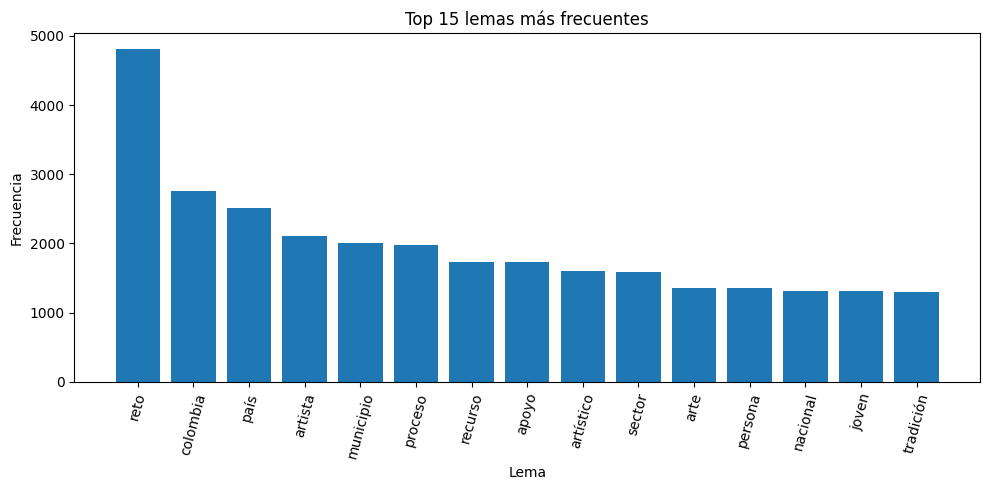

In [19]:
plt.figure(figsize=(10, 5))
plt.bar(top_lemmas.head(15)["lemma"], top_lemmas.head(15)["freq"])
plt.xticks(rotation=75)
plt.title("Top 15 lemas más frecuentes")
plt.xlabel("Lema")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()


## 10. Corpus listo para Word2Vec

Ya tenemos dos posibles corpus para entrenar embeddings:

- `corpus_tokens`: usa tokens limpios,
- `corpus_lemmas`: usa lemas limpios.

En español, muchas veces `corpus_lemmas` ayuda a consolidar variantes morfológicas.  
Sin embargo, si quieres preservar formas originales, puedes usar `corpus_tokens`.


In [20]:
corpus_tokens: List[List[str]] = df_model["tokens"].tolist()
corpus_lemmas: List[List[str]] = df_model["lemmas"].tolist()

print("Ejemplo corpus_tokens[0]:", corpus_tokens[0][:20])
print("Ejemplo corpus_lemmas[0]:", corpus_lemmas[0][:20])


Ejemplo corpus_tokens[0]: ['reto', 'actualizar', 'desarrollo', 'país', 'contexto', 'actual', 'realmente', 'transversal', 'desarrollo', 'social', 'económico', 'político', 'vehículo', 'transformación', 'sociedad', 'post', 'conflicto']
Ejemplo corpus_lemmas[0]: ['reto', 'actualizar', 'desarrollo', 'país', 'contexto', 'actual', 'realmente', 'transversal', 'desarrollo', 'social', 'económico', 'político', 'vehículo', 'transformación', 'sociedad', 'post', 'conflicto']


## 11. Opcional: prueba rápida de Word2Vec

Aquí solo dejamos una prueba mínima para verificar que el corpus ya sirve como entrada.
El entrenamiento serio lo puedes dejar para el notebook anterior o uno posterior.


In [21]:
from gensim.models import Word2Vec

w2v_demo = Word2Vec(
    sentences=corpus_lemmas,
    vector_size=50,
    window=5,
    min_count=3,
    workers=1,
    sg=1,
    negative=10,
    epochs=20,
    seed=7,
)

print(w2v_demo)
print("Tamaño vocabulario Word2Vec:", len(w2v_demo.wv))


Word2Vec<vocab=5616, vector_size=50, alpha=0.025>
Tamaño vocabulario Word2Vec: 5616


In [22]:
candidate_words = [w for w in ["arte", "patrimonio", "formación", "territorio", "sabedor", "comunidad"] if w in w2v_demo.wv]

for w in candidate_words[:5]:
    print(f"\nPalabra objetivo: {w}")
    print(w2v_demo.wv.most_similar(w, topn=5))



Palabra objetivo: arte
[('entretener', 0.759109377861023), ('tabú', 0.7499582171440125), ('art', 0.7430427670478821), ('artes', 0.7388976812362671), ('llamar él', 0.7267148494720459)]

Palabra objetivo: patrimonio
[('inmaterial', 0.8518880605697632), ('conservacion', 0.7775907516479492), ('arquitectónico', 0.7698160409927368), ('materio', 0.7604956030845642), ('salvaguardar', 0.7432263493537903)]

Palabra objetivo: formación
[('proceso', 0.8169952630996704), ('formativo', 0.7865487933158875), ('natación', 0.7794010639190674), ('infraestructuro', 0.7786501049995422), ('artístico', 0.7630143761634827)]

Palabra objetivo: territorio
[('periferia', 0.7701453566551208), ('demográfico', 0.7639085650444031), ('comunidad', 0.7518629431724548), ('periférico', 0.7503038048744202), ('región', 0.7471925616264343)]

Palabra objetivo: sabedor
[('partera', 0.7438090443611145), ('portador', 0.7419418692588806), ('mercantilización', 0.7199729681015015), ('robusta', 0.7137295007705688), ('loable', 0.70

## 12. Exportación de artefactos

Guardaremos:

1. un CSV con el dataset limpio,
2. un archivo TXT con un documento por línea usando lemas,
3. un archivo TXT con un documento por línea usando tokens.

Esto te permite reutilizar el corpus en otros notebooks o proyectos.


In [23]:
EXPORT_DIR = Path("outputs")
EXPORT_DIR.mkdir(exist_ok=True)

df_export = df_model[[
    "ID",
    "Reto",
    "text_clean",
    "text_norm_dedup",
    "tokens",
    "lemmas",
    "n_tokens",
    "n_lemmas",
]].copy()

# Convert list columns to strings for CSV export
df_export["tokens_str"] = df_export["tokens"].apply(lambda x: " ".join(x))
df_export["lemmas_str"] = df_export["lemmas"].apply(lambda x: " ".join(x))

csv_path = EXPORT_DIR / "retos_culturales_preprocesado.csv"
tokens_txt_path = EXPORT_DIR / "corpus_tokens.txt"
lemmas_txt_path = EXPORT_DIR / "corpus_lemmas.txt"

df_export.to_csv(csv_path, index=False, encoding="utf-8")

with open(tokens_txt_path, "w", encoding="utf-8") as f:
    for doc in corpus_tokens:
        f.write(" ".join(doc) + "\n")

with open(lemmas_txt_path, "w", encoding="utf-8") as f:
    for doc in corpus_lemmas:
        f.write(" ".join(doc) + "\n")

print("Saved files:")
print(csv_path)
print(tokens_txt_path)
print(lemmas_txt_path)


Saved files:
outputs\retos_culturales_preprocesado.csv
outputs\corpus_tokens.txt
outputs\corpus_lemmas.txt


## 13. Recomendaciones metodológicas

### Sobre duplicados
- Si hay respuestas copiadas o casi idénticas, eliminarlas evita sesgar el embedding.
- También podrías conservarlas si quisieras modelar “peso social” de ciertos discursos, pero eso ya sería otra decisión analítica.

### Sobre stopwords
- Para Word2Vec, quitarlas o no quitarlas depende del objetivo.
- Si te interesa estructura semántica temática, suele ayudar quitarlas.
- Si te interesa estructura más sintáctica/contextual, puedes conservar parte de ellas.

### Sobre lematización
- En español suele ser útil para reducir dispersión del vocabulario.
- Pero a veces puede borrar matices si el modelo de lematización no es muy fino.

### Sobre `min_count`
- En un corpus de este tamaño, un `min_count` de 2 o 3 suele ser razonable.
- Si lo subes mucho, puedes perder términos importantes pero poco frecuentes.


## 14. Resumen

En este notebook hicimos un pipeline más cercano a un caso real:

1. cargamos el Excel original,  
2. limpiamos y normalizamos el texto,  
3. detectamos duplicados de forma más robusta,  
4. tokenizamos y lematizamos con spaCy,  
5. filtramos documentos demasiado cortos,  
6. construimos el corpus final listo para Word2Vec,  
7. exportamos artefactos reutilizables.

Con esto ya tienes una base mucho más sólida para seguir con:
- Word2Vec,
- FastText,
- clustering de documentos,
- visualización de embeddings,
- clasificación temática.


## 15. Ejercicios sugeridos

1. Compara `corpus_tokens` vs `corpus_lemmas` al entrenar Word2Vec.  
2. Repite el pipeline sin quitar stopwords y compara vecinos semánticos.  
3. Cambia el umbral de longitud mínima del documento (`n_tokens >= 3`).  
4. Construye bigramas frecuentes antes de entrenar Word2Vec.  
5. Evalúa si conviene quitar palabras demasiado generales como `país`, `sector`, `proceso`, etc.
